# Phase 2 — Notebook 06 · Stage 2.2 follow-up · Class-balanced loss head-to-head

**Why this notebook exists.** Notebook 05 suggested that the L2/3 failure may be partly affected by the training objective or class-decision trade-off, because many L2/3 errors were near-boundary, especially under mean pooling. This notebook tests a milder, principled class-balanced weighting scheme. the inverse-frequency class-weighted CE up-weights L6 by ~1.77× and L2/3 by ~1.14× (vs L4 0.69, L5 0.91). This drives systematic over-prediction of L6 and under-prediction of L2/3. The user proposes a milder, principled alternative: the **class-balanced loss** of *Cui et al. 2019, "Class-Balanced Loss Based on Effective Number of Samples"*:

$$
w_c \;\propto\; \frac{1 - \beta}{1 - \beta^{n_c}}\,, \qquad \sum_c w_c = K,
$$

with $\beta = 0.999$ (paper's canonical value) and $K = 4$ classes. The effective-number formulation interpolates smoothly between uniform ($\beta=0$) and inverse-frequency ($\beta\to 1$); at $\beta=0.999$ on our 5_6 training folds it gives weights roughly $(L2/3, L4, L5, L6) \approx (1.01, 0.63, 0.82, 1.55)$ — much closer to uniform than inverse-frequency $(1.14, 0.69, 0.91, 1.77)$.

**Three architectures compared (paired by fold, identical seeds, identical data):**

| Model | Architecture | Loss |
|---|---|---|
| **A** | Design B + hash embedding + **mean pool**         | inverse-frequency (loaded from NB 04) |
| **B** | Design B + hash embedding + **attention pool**    | inverse-frequency (loaded from NB 04) |
| **C** | Design B + hash embedding + **mean pool**         | **class-balanced** (β=0.999) — trained here |

**Decision rule** (user-specified — applied in §12):

* If model **C** improves L2/3 recall by ≥ 5 pp **and** improves macro-F1 vs model **A** → **keep class-balanced loss** as the new training default.
* If model **C** improves L2/3 recall by ≥ 5 pp **but** L4 or L5 recall drops by ≥ 5 pp → **reject** (class-balanced is over-correcting, just trades one collapse for another).
* Otherwise (no meaningful change in L2/3) → **stop single-session tuning** and proceed to Stage 2.3 (replication on session 5_7) with the strongest existing model.

**Compute.** Model C is 5 GKF folds × 1 condition (`raw_identity`) = 5 fits, ~3–5 min/fit on MPS = ~15–25 min total. Models A and B are loaded from `phase2_stage2_2a_hash_aware_design_b.parquet` (no re-training).

**Methodological notes (binding):**

1. **Same 5 GKF folds, same population, same session 5_6** as notebooks 04–05. Per-fold seeds = `SEED + fold_k = {42, 43, 44, 45, 46}` (matches NB 04 model A exactly except for the loss).
2. **Weights recomputed per training fold.** `get_class_balanced_weights(y_train_fold)` — never sees test fold, never sees val fold (matches the user's binding constraint).
3. **No architectural change.** Only the loss-weighting scheme differs from model A. This isolates the loss as the single intervention.
4. **Reportable as `E1 Design B + hash identity + class-balanced`**, NOT as a trace-only or amplitude claim — the trace-only reading still comes from notebook 02.

Outputs: `data/processed/results/phase2_stage2_2_class_balanced_loss.parquet`.

## 0 · Environment

In [1]:
import os, sys, time, warnings
from pathlib import Path

PROJECT_ROOT = Path(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.model_selection import GroupKFold

from src.config import PROCESSED_RESULTS_DIR
from src.data.loaders import load_working_pop
from src.features.raw_traces import (
    remove_mismatch_neurons,
    build_single_session_e1,
    MAX_TRACE_LEN,
    load_oracle_hashes,
)
from src.models.cnn import (
    LAYER_CLASSES,
    get_class_weights,
    get_class_balanced_weights,
)
from src.models.cnn_deepsets import (
    HashAwareDeepSetsTraceCNN,
    build_e1_neuron_tensors_with_hashes,
    train_design_b_hash_fold,
    predict_neuron_proba_hash,
    neuron_score_design_b,
)
from src.eval.cnn_eval import save_results, make_result_row

warnings.filterwarnings('ignore', category=UserWarning)

SEED        = 42
N_FOLDS     = 5
SESSION     = '5_6'
MAX_EPOCHS  = 80
PATIENCE    = 12
BATCH_SIZE  = 32
TRACE_EMBED = 64
HASH_EMBED  = 16
ROW_HIDDEN  = 64
HEAD_HIDDEN = 64
CB_BETA     = 0.999            # Cui et al. 2019 canonical value

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print(f'Device       : {DEVICE}')
print(f'Loss kind    : class_balanced (Cui et al. 2019, β={CB_BETA})')
print(f'Architecture : DeepSets-CNN + hash embedding + mean pool (matches NB 04 model A)')
print(f'CV protocol  : GroupKFold(n_splits={N_FOLDS}) by nucleus_id  (matches NB 04 / NB 05)')
print(f'Compute      : {N_FOLDS} fits ≈ 15–25 min on MPS')

Device       : mps
Loss kind    : class_balanced (Cui et al. 2019, β=0.999)
Architecture : DeepSets-CNN + hash embedding + mean pool (matches NB 04 model A)
CV protocol  : GroupKFold(n_splits=5) by nucleus_id  (matches NB 04 / NB 05)
Compute      : 5 fits ≈ 15–25 min on MPS


## 1 · Data, hash vocabulary, GKF folds, set tensors

Reproduces the notebook-04 setup exactly so the per-fold results re-derived here are paired with NB 04's models A and B at the fold-and-neuron level.

In [2]:
units_raw = load_working_pop()
units_clean, _ = remove_mismatch_neurons(units_raw, verbose=False)
df_session = build_single_session_e1(SESSION, units_clean, verbose=False)
n_neurons = df_session['nucleus_id'].nunique()

oracle_hashes, _ = load_oracle_hashes()
HASH_VOCAB = sorted(oracle_hashes)
N_HASHES   = len(HASH_VOCAB)

neurons_df = df_session[['nucleus_id', 'layer_label']].drop_duplicates().reset_index(drop=True)
neuron_ids = neurons_df['nucleus_id'].to_numpy()
gkf = GroupKFold(n_splits=N_FOLDS)
fold_of_neuron = np.full(len(neuron_ids), -1, dtype=np.int8)
for k, (_, te_idx) in enumerate(gkf.split(neuron_ids, groups=neuron_ids)):
    fold_of_neuron[te_idx] = k
neurons_df['gkf_fold'] = fold_of_neuron
df_session = df_session.merge(neurons_df[['nucleus_id', 'gkf_fold']], on='nucleus_id', how='left')

X, mask, y_str, nids, hash_ids, hash_vocab = build_e1_neuron_tensors_with_hashes(
    df_session, pad_to=MAX_TRACE_LEN, hash_vocab=HASH_VOCAB,
)
fold_lookup = neurons_df.set_index('nucleus_id')['gkf_fold'].to_dict()
fold_of = np.array([fold_lookup[int(n)] for n in nids], dtype=np.int8)

print(f'X        : {X.shape}  dtype={X.dtype}')
print(f'hash_ids : {hash_ids.shape}')
print(f'fold_of  : counts {dict(zip(*np.unique(fold_of, return_counts=True)))}')
print(f'Total session neurons: {n_neurons}')

X        : (685, 116, 113)  dtype=float32
hash_ids : (116,)
fold_of  : counts {0: 137, 1: 137, 2: 137, 3: 137, 4: 137}
Total session neurons: 685


## 2 · Display the two weight schemes side-by-side

For each training fold (i.e. excluding test fold $k$ AND val fold $(k+1)\bmod 5$), compute both inverse-frequency and class-balanced weights and tabulate. This is the *exact* weighting the optimizer will see — read directly off the training labels, no normalisation tricks.

In [3]:
rows = []
for k in range(N_FOLDS):
    val_k = (k + 1) % N_FOLDS
    train_idx = np.where(~np.isin(fold_of, [k, val_k]))[0]
    y_train_fold = y_str[train_idx]
    counts = {c: int((y_train_fold == c).sum()) for c in LAYER_CLASSES}

    w_if = get_class_weights(y_train_fold, classes=LAYER_CLASSES, device='cpu').numpy()
    w_cb = get_class_balanced_weights(y_train_fold, classes=LAYER_CLASSES, beta=CB_BETA, device='cpu').numpy()

    for ci, c in enumerate(LAYER_CLASSES):
        rows.append({
            'fold':              k,
            'class':             c,
            'n_train':           counts[c],
            'w_inverse_freq':    f'{w_if[ci]:.3f}',
            'w_class_balanced':  f'{w_cb[ci]:.3f}',
            'ratio_CB_over_IF':  f'{(w_cb[ci] / w_if[ci]):.3f}',
        })
weights_df = pd.DataFrame(rows)
print('Per-fold class weights (the optimiser sees one of these schemes):\n')
print(weights_df.to_string(index=False))
print()
print(f'Reading: ratio_CB_over_IF < 1 means class-balanced down-weights this class vs inverse-freq.')
print(f'  L6  : CB << IF — much milder up-weighting (target: stop over-predicting L6)')
print(f'  L2/3: CB ≈ IF or slightly lower (mild change for L2/3 weight)')
print(f'  L4  : CB ≈ IF (slight down-weight)')
print(f'  L5  : CB ≈ IF (slight down-weight)')

Per-fold class weights (the optimiser sees one of these schemes):

 fold class  n_train w_inverse_freq w_class_balanced ratio_CB_over_IF
    0  L2/3       90          1.142            1.009            0.884
    0    L4      148          0.694            0.631            0.909
    0    L5      116          0.886            0.793            0.895
    0    L6       57          1.803            1.567            0.869
    1  L2/3       93          1.105            0.982            0.889
    1    L4      146          0.704            0.642            0.912
    1    L5      115          0.893            0.803            0.898
    1    L6       57          1.803            1.574            0.873
    2  L2/3       93          1.105            0.985            0.892
    2    L4      148          0.694            0.636            0.916
    2    L5      112          0.917            0.826            0.900
    2    L6       58          1.772            1.553            0.877
    3  L2/3       90   

## 3 · Per-fold runner with class-balanced loss

Same protocol as notebook 04, *except* `loss_kind='class_balanced'` is passed through to `train_design_b_hash_fold`. Per-fold seeds, batch size, optimizer, scheduler, early stopping all match NB 04 model A — so the only intervention is the loss weighting.

In [4]:
def run_class_balanced_fold(fold_k: int, seed: int = SEED, verbose: bool = False):
    val_k = (fold_k + 1) % N_FOLDS

    test_idx  = np.where(fold_of == fold_k)[0]
    val_idx   = np.where(fold_of == val_k)[0]
    train_idx = np.where(~np.isin(fold_of, [fold_k, val_k]))[0]

    assert (not (set(train_idx) & set(val_idx))) and (not (set(train_idx) & set(test_idx))) \
        and (not (set(val_idx) & set(test_idx))), 'neuron leakage detected'

    X_tr, M_tr, y_tr = X[train_idx], mask[train_idx], y_str[train_idx]
    X_va, M_va, y_va = X[val_idx],   mask[val_idx],   y_str[val_idx]
    X_te, M_te, y_te = X[test_idx],  mask[test_idx],  y_str[test_idx]

    model, history = train_design_b_hash_fold(
        X_tr, M_tr, y_tr,
        X_va, M_va, y_va,
        hash_ids=hash_ids,
        n_hashes=N_HASHES,
        in_channels=1, n_classes=4,
        trace_embed=TRACE_EMBED, hash_embed=HASH_EMBED,
        row_hidden=ROW_HIDDEN, head_hidden=HEAD_HIDDEN,
        dropout=0.25, kernel_size=5,
        pool='mean',                          # same as NB 04 model A
        batch_size=BATCH_SIZE,
        max_epochs=MAX_EPOCHS, patience=PATIENCE,
        lr=1e-3, weight_decay=1e-4,
        seed=seed + fold_k,                   # same as NB 04 model A
        device=DEVICE,
        verbose=verbose,
        loss_kind='class_balanced',           # the only intervention
        cb_beta=CB_BETA,
    )

    neuron_probs = predict_neuron_proba_hash(
        model, X_te, hash_ids, mask=M_te,
        batch_size=BATCH_SIZE, device=DEVICE,
    )
    score = neuron_score_design_b(y_te, neuron_probs, classes=np.array(LAYER_CLASSES))
    return score, history, neuron_probs, y_te, np.array([int(nids[i]) for i in test_idx])

print('Class-balanced runner ready.')

Class-balanced runner ready.


## 4 · Run 5 folds (model C — class-balanced)

In [5]:
results_C    = []
histories_C  = []
preds_rows   = []     # for downstream diagnostics if needed

t0 = time.time()
print(f'\n────────  Model C: hash-aware Design B + mean pool + class-balanced (β={CB_BETA})  ────────')
for k in range(N_FOLDS):
    ti = time.time()
    score, hist, probs, y_te, nids_te = run_class_balanced_fold(fold_k=k, seed=SEED, verbose=False)
    score['fold'] = k
    results_C.append(score)
    histories_C.append(hist)
    y_pred = np.array(LAYER_CLASSES)[probs.argmax(axis=1)]
    for i, nid in enumerate(nids_te):
        preds_rows.append({
            'fold': k, 'nucleus_id': int(nid),
            'true_layer': y_te[i], 'pred_layer': y_pred[i],
            **{f'p_{c.replace("/","")}': float(probs[i, j]) for j, c in enumerate(LAYER_CLASSES)},
        })
    ba = score['balanced_accuracy']; pcr = score['per_class_recall']
    print(f'  fold {k} | n_test={score["n_neurons"]:3d} | bal_acc={ba:.4f} | recall: '
          + ' '.join(f'{c}={pcr[c]:.2f}' for c in LAYER_CLASSES)
          + f'  ({time.time() - ti:.1f}s)')
print(f'\nTotal training time: {(time.time() - t0) / 60:.1f} min')


────────  Model C: hash-aware Design B + mean pool + class-balanced (β=0.999)  ────────
  fold 0 | n_test=137 | bal_acc=0.5115 | recall: L2/3=0.03 L4=0.62 L5=0.50 L6=0.89  (32.9s)
  fold 1 | n_test=137 | bal_acc=0.5058 | recall: L2/3=0.55 L4=0.00 L5=0.62 L6=0.85  (39.2s)
  fold 2 | n_test=137 | bal_acc=0.4870 | recall: L2/3=0.00 L4=0.54 L5=0.57 L6=0.84  (35.6s)
  fold 3 | n_test=137 | bal_acc=0.5998 | recall: L2/3=0.10 L4=0.67 L5=0.68 L6=0.95  (32.6s)
  fold 4 | n_test=137 | bal_acc=0.5557 | recall: L2/3=0.09 L4=0.49 L5=0.69 L6=0.95  (76.7s)

Total training time: 3.6 min


## 5 · Load models A and B from notebook 04

Per-fold paired comparisons need the exact NB 04 fold scores. We load them from `phase2_stage2_2a_hash_aware_design_b.parquet` (model_name = `…_meanpool` for A, `…_attnpool` for B).

In [6]:
nb04_path = Path('data/processed/results/phase2_stage2_2a_hash_aware_design_b.parquet')
if not nb04_path.exists():
    raise FileNotFoundError(f'NB 04 results not found at {nb04_path}. Run notebook 04 first.')
df_04 = pd.read_parquet(nb04_path)

MODEL_NAMES = {
    'A': 'HashAwareDeepSetsCNN_E1_raw_identity_meanpool',
    'B': 'HashAwareDeepSetsCNN_E1_raw_identity_attnpool',
}

def load_per_fold(df, model_name):
    sub = df[(df['model_name'] == model_name) &
             (df['fold_or_session'].str.contains('fold'))].copy()
    sub['fold'] = sub['fold_or_session'].str.extract(r'fold(\d+)$').astype(int)
    sub = sub.sort_values('fold')
    if len(sub) != N_FOLDS:
        raise RuntimeError(f'expected {N_FOLDS} fold rows for {model_name}; got {len(sub)}')
    return sub

RECALL_COL = {'L2/3':'recall_L23', 'L4':'recall_L4', 'L5':'recall_L5', 'L6':'recall_L6'}

def to_per_fold_dict(sub):
    return {
        'bal_acc':  sub['balanced_accuracy'].to_numpy(),
        'macro_f1': sub['macro_f1'].to_numpy(),
        'recall':   {c: sub[RECALL_COL[c]].to_numpy() for c in LAYER_CLASSES},
    }

A_sub = load_per_fold(df_04, MODEL_NAMES['A']); A = to_per_fold_dict(A_sub)
B_sub = load_per_fold(df_04, MODEL_NAMES['B']); B = to_per_fold_dict(B_sub)

# Model C from this notebook's results
C = {
    'bal_acc':  np.array([s['balanced_accuracy'] for s in results_C]),
    'macro_f1': np.array([s['macro_f1']          for s in results_C]),
    'recall':   {c: np.array([s['per_class_recall'][c] for s in results_C]) for c in LAYER_CLASSES},
}

print('Loaded NB 04 model A (mean pool + IF) per-fold bal-acc:', np.round(A['bal_acc'], 4))
print('Loaded NB 04 model B (attn pool + IF) per-fold bal-acc:', np.round(B['bal_acc'], 4))
print('Model C  (mean pool + CB) per-fold bal-acc            :', np.round(C['bal_acc'], 4))

Loaded NB 04 model A (mean pool + IF) per-fold bal-acc: [0.5067 0.504  0.487  0.5874 0.5386]
Loaded NB 04 model B (attn pool + IF) per-fold bal-acc: [0.5995 0.5232 0.6033 0.544  0.5723]
Model C  (mean pool + CB) per-fold bal-acc            : [0.5115 0.5058 0.487  0.5998 0.5557]


## 6 · Three-way summary table — A, B, C

Each row is mean ± SD across 5 folds. Same population, same partition, same seed strategy across all three rows; the only differences are pool layer (A/B vs B) and loss weighting (A/B vs C).

In [7]:
def fmt(arr):
    return f'{arr.mean():.4f} ± {arr.std(ddof=0):.4f}'
def fmtr(arr):
    return f'{arr.mean():.3f} ± {arr.std(ddof=0):.3f}'

rows = []
for label, M in [('A · mean pool · inverse_freq',     A),
                  ('B · attention pool · inverse_freq', B),
                  ('C · mean pool · class_balanced',    C)]:
    rows.append({
        'model':    label,
        'bal_acc':  fmt(M['bal_acc']),
        'macro_F1': fmt(M['macro_f1']),
        'L2/3':     fmtr(M['recall']['L2/3']),
        'L4':       fmtr(M['recall']['L4']),
        'L5':       fmtr(M['recall']['L5']),
        'L6':       fmtr(M['recall']['L6']),
    })
summary_df = pd.DataFrame(rows).set_index('model')
print(f'Stage 2.2 follow-up · session {SESSION} · raw_identity · 5-fold GKF\n')
print(summary_df.to_string())

Stage 2.2 follow-up · session 5_6 · raw_identity · 5-fold GKF

                                           bal_acc         macro_F1           L2/3             L4             L5             L6
model                                                                                                                          
A · mean pool · inverse_freq       0.5247 ± 0.0355  0.4689 ± 0.0552  0.169 ± 0.190  0.439 ± 0.235  0.606 ± 0.084  0.886 ± 0.038
B · attention pool · inverse_freq  0.5685 ± 0.0311  0.5252 ± 0.0343  0.060 ± 0.046  0.648 ± 0.121  0.638 ± 0.163  0.927 ± 0.063
C · mean pool · class_balanced     0.5320 ± 0.0407  0.4758 ± 0.0552  0.156 ± 0.202  0.464 ± 0.241  0.611 ± 0.071  0.896 ± 0.045


## 7 · Paired per-fold deltas — three pairwise comparisons

The decision rule lives on **C − A** (matched architecture, only loss differs). C − B is informative as a cross-check (does class-balanced + mean compete with attention pool?). B − A is for context (NB 04's main finding).

In [8]:
def metric_lines(name, lhs, rhs):
    rows = []
    for metric_name, key, sub in [
        ('balanced_accuracy', 'bal_acc',  None),
        ('macro_F1',          'macro_f1', None),
        ('recall_L2/3',       'recall',   'L2/3'),
        ('recall_L4',         'recall',   'L4'),
        ('recall_L5',         'recall',   'L5'),
        ('recall_L6',         'recall',   'L6'),
    ]:
        a = lhs[key][sub] if sub else lhs[key]
        b = rhs[key][sub] if sub else rhs[key]
        d = a - b
        rows.append({
            'metric':   metric_name,
            'fold0': f'{d[0]:+.3f}', 'fold1': f'{d[1]:+.3f}',
            'fold2': f'{d[2]:+.3f}', 'fold3': f'{d[3]:+.3f}',
            'fold4': f'{d[4]:+.3f}',
            'mean Δ': f'{d.mean():+.4f}',
            'std Δ':  f'{d.std(ddof=0):.4f}',
            'n_pos/5': int((d > 0).sum()),
        })
    print(f'\nPer-fold Δ · {name}:')
    print(pd.DataFrame(rows).set_index('metric').to_string())

metric_lines('C − A   (class-balanced − inverse-freq, both mean pool)', C, A)
metric_lines('C − B   (class-balanced + mean − inverse-freq + attention)', C, B)
metric_lines('B − A   (attention − mean, both inverse-freq, NB 04 result)', B, A)


Per-fold Δ · C − A   (class-balanced − inverse-freq, both mean pool):
                    fold0   fold1   fold2   fold3   fold4   mean Δ   std Δ  n_pos/5
metric                                                                             
balanced_accuracy  +0.005  +0.002  +0.000  +0.012  +0.017  +0.0072  0.0065        4
macro_F1           +0.019  +0.001  +0.000  -0.000  +0.015  +0.0069  0.0082        3
recall_L2/3        +0.031  +0.034  +0.000  -0.034  -0.094  -0.0125  0.0477        2
recall_L4          -0.040  +0.000  +0.000  +0.082  +0.085  +0.0253  0.0496        2
recall_L5          +0.028  -0.027  +0.000  -0.050  +0.077  +0.0055  0.0442        2
recall_L6          +0.000  +0.000  +0.000  +0.053  +0.000  +0.0105  0.0211        1

Per-fold Δ · C − B   (class-balanced + mean − inverse-freq + attention):
                    fold0   fold1   fold2   fold3   fold4   mean Δ   std Δ  n_pos/5
metric                                                                             
balanced_accura

## 8 · Predicted class distribution vs true distribution

If class-balanced loss does its job, model C's predicted prior should be closer to the true prior than model A's (less L6 over-prediction, more L2/3). We can only compute this for model C from this notebook's per-neuron predictions, but we summarise the diagnostic here for reference; for models A and B see notebook 05.

In [9]:
df_C_pred = pd.DataFrame(preds_rows)
true_total = df_C_pred['true_layer'].value_counts().reindex(LAYER_CLASSES, fill_value=0)
pred_total = df_C_pred['pred_layer'].value_counts().reindex(LAYER_CLASSES, fill_value=0)
n = int(true_total.sum())
rows = []
for c in LAYER_CLASSES:
    rows.append({
        'class':            c,
        'true_count':       int(true_total[c]),
        'true_frac':        f'{true_total[c] / n:.3f}',
        'pred_count_C':     int(pred_total[c]),
        'pred_frac_C':      f'{pred_total[c] / n:.3f}',
        'C_Δfrac':          f'{(pred_total[c] - true_total[c]) / n:+.3f}',
    })
print(f'Class prior — model C (class-balanced) · all folds (n={n}):\n')
print(pd.DataFrame(rows).set_index('class').to_string())

true_p = (true_total / n).to_numpy(dtype=np.float64)
C_p    = (pred_total / n).to_numpy(dtype=np.float64)
print(f'\nL1 distance to true prior (smaller = better):  model C = {np.abs(C_p - true_p).sum():.3f}')
print('  (For models A and B see notebook 05 §9; the value to beat there for L1 distance.)')

Class prior — model C (class-balanced) · all folds (n=685):

       true_count true_frac  pred_count_C pred_frac_C C_Δfrac
class                                                        
L2/3          151     0.220            79       0.115  -0.105
L4            249     0.364           230       0.336  -0.028
L5            189     0.276           260       0.380  +0.104
L6             96     0.140           116       0.169  +0.029

L1 distance to true prior (smaller = better):  model C = 0.266
  (For models A and B see notebook 05 §9; the value to beat there for L1 distance.)


## 9 · Per-fold L2/3 stability across A, B, C

We can directly compute fold-level L2/3 recall for all three models from per-fold stored values (loaded for A and B, computed for C).

In [10]:
rows = []
for k in range(N_FOLDS):
    val_k = (k + 1) % N_FOLDS
    train_idx = np.where(~np.isin(fold_of, [k, val_k]))[0]
    n_train_l23 = int((y_str[train_idx] == 'L2/3').sum())
    test_idx = np.where(fold_of == k)[0]
    n_test_l23  = int((y_str[test_idx]  == 'L2/3').sum())
    rows.append({
        'fold': k,
        'n_train_L23':   n_train_l23,
        'n_test_L23':    n_test_l23,
        'A_L2/3_recall': f'{A["recall"]["L2/3"][k]:.3f}',
        'B_L2/3_recall': f'{B["recall"]["L2/3"][k]:.3f}',
        'C_L2/3_recall': f'{C["recall"]["L2/3"][k]:.3f}',
        'C − A':         f'{C["recall"]["L2/3"][k] - A["recall"]["L2/3"][k]:+.3f}',
    })
stab_df = pd.DataFrame(rows).set_index('fold')
print('Per-fold L2/3 recall across A, B, C:\n')
print(stab_df.to_string())

Per-fold L2/3 recall across A, B, C:

      n_train_L23  n_test_L23 A_L2/3_recall B_L2/3_recall C_L2/3_recall   C − A
fold                                                                           
0              90          32         0.000         0.062         0.031  +0.031
1              93          29         0.517         0.000         0.552  +0.034
2              93          29         0.000         0.069         0.000  +0.000
3              90          29         0.138         0.138         0.103  -0.034
4              87          32         0.188         0.031         0.094  -0.094


## 10 · Plots — three-way bal-acc and per-class recall, plus model-C training curves

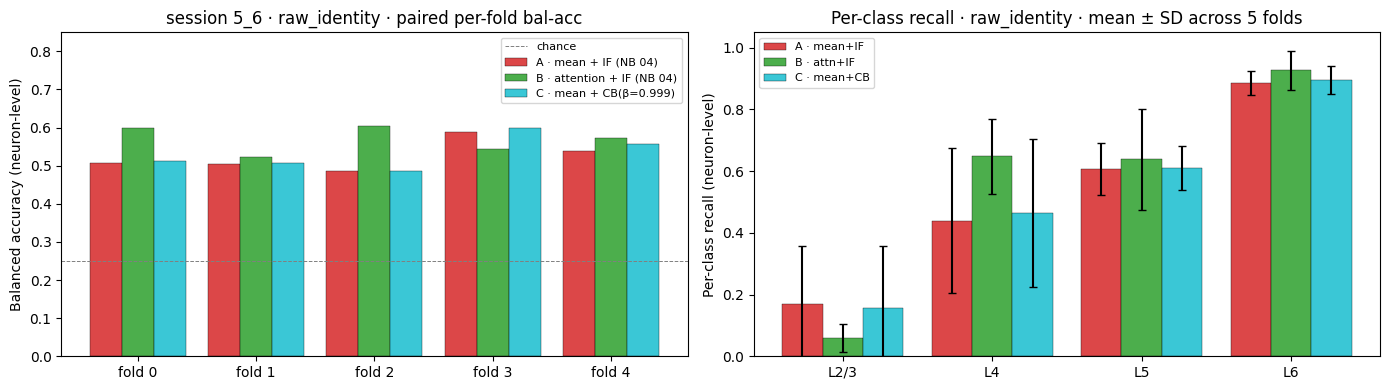

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# (a) Per-fold bal-acc — three-way grouped bars
ax = axes[0]
x = np.arange(N_FOLDS)
w = 0.27
ax.bar(x - w, A['bal_acc'], w, label='A · mean + IF (NB 04)',
       color='C3', alpha=0.85, edgecolor='k', linewidth=0.3)
ax.bar(x,     B['bal_acc'], w, label='B · attention + IF (NB 04)',
       color='C2', alpha=0.85, edgecolor='k', linewidth=0.3)
ax.bar(x + w, C['bal_acc'], w, label=f'C · mean + CB(β={CB_BETA})',
       color='C9', alpha=0.85, edgecolor='k', linewidth=0.3)
ax.axhline(0.25, color='gray', ls='--', lw=0.7, label='chance')
ax.set_xticks(x); ax.set_xticklabels([f'fold {k}' for k in range(N_FOLDS)])
ax.set_ylabel('Balanced accuracy (neuron-level)')
ax.set_title(f'session {SESSION} · raw_identity · paired per-fold bal-acc')
ax.legend(fontsize=8, loc='upper right')
y_top = max(0.85, A['bal_acc'].max() + 0.05, B['bal_acc'].max() + 0.05, C['bal_acc'].max() + 0.05)
ax.set_ylim(0.0, y_top)

# (b) Per-class recall — three-way grouped bars (mean ± SD)
ax = axes[1]
x = np.arange(len(LAYER_CLASSES)); w = 0.27
for offset, M, label, color in [(-w, A, 'A · mean+IF', 'C3'),
                                ( 0, B, 'B · attn+IF', 'C2'),
                                (+w, C, 'C · mean+CB', 'C9')]:
    means = np.array([M['recall'][c].mean() for c in LAYER_CLASSES])
    stds  = np.array([M['recall'][c].std(ddof=0) for c in LAYER_CLASSES])
    ax.bar(x + offset, means, w, yerr=stds, capsize=3, label=label,
           color=color, alpha=0.85, edgecolor='k', linewidth=0.3)
ax.set_xticks(x); ax.set_xticklabels(LAYER_CLASSES)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Per-class recall (neuron-level)')
ax.set_title('Per-class recall · raw_identity · mean ± SD across 5 folds')
ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

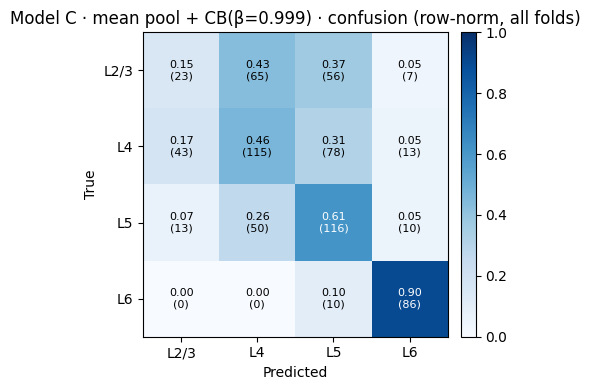

In [12]:
# Model C confusion matrix (sum across folds, row-normalised)
fig, ax = plt.subplots(figsize=(5, 4))
Cm = sum(s['confusion_matrix'] for s in results_C)
Cn = Cm / Cm.sum(axis=1, keepdims=True).clip(min=1)
im = ax.imshow(Cn, vmin=0, vmax=1, cmap='Blues')
for i in range(Cm.shape[0]):
    for j in range(Cm.shape[1]):
        ax.text(j, i, f'{Cn[i,j]:.2f}\n({Cm[i,j]})',
                ha='center', va='center', fontsize=8,
                color='white' if Cn[i,j] > 0.5 else 'black')
ax.set_xticks(range(len(LAYER_CLASSES))); ax.set_xticklabels(LAYER_CLASSES)
ax.set_yticks(range(len(LAYER_CLASSES))); ax.set_yticklabels(LAYER_CLASSES)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'Model C · mean pool + CB(β={CB_BETA}) · confusion (row-norm, all folds)')
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.03)
plt.tight_layout(); plt.show()

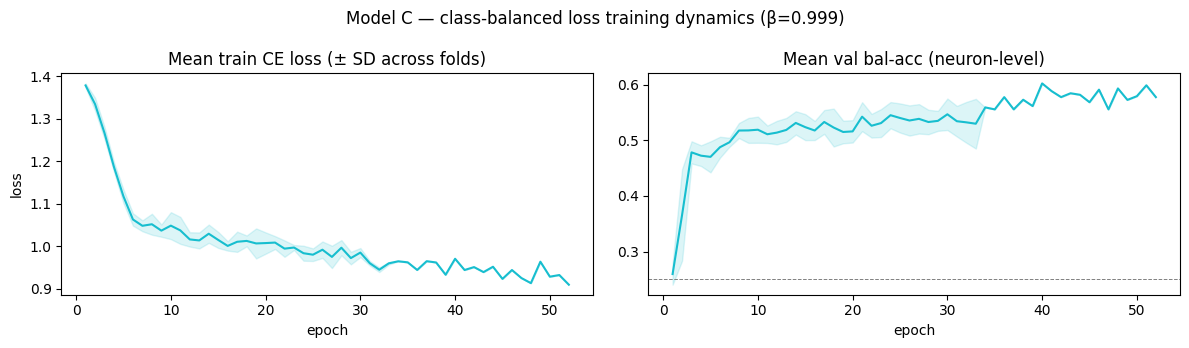

In [13]:
# Model C training curves (mean ± SD across folds)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
max_e = max(len(h) for h in histories_C)
loss = np.full((len(histories_C), max_e), np.nan)
vacc = np.full((len(histories_C), max_e), np.nan)
for i, h in enumerate(histories_C):
    loss[i, :len(h)] = [r['train_loss']  for r in h]
    vacc[i, :len(h)] = [r['val_bal_acc'] for r in h]
epochs = np.arange(1, max_e + 1)
axes[0].plot(epochs, np.nanmean(loss, 0), color='C9')
axes[0].fill_between(epochs,
                     np.nanmean(loss, 0) - np.nanstd(loss, 0),
                     np.nanmean(loss, 0) + np.nanstd(loss, 0), color='C9', alpha=0.15)
axes[1].plot(epochs, np.nanmean(vacc, 0), color='C9')
axes[1].fill_between(epochs,
                     np.nanmean(vacc, 0) - np.nanstd(vacc, 0),
                     np.nanmean(vacc, 0) + np.nanstd(vacc, 0), color='C9', alpha=0.15)
axes[0].set(title='Mean train CE loss (± SD across folds)', xlabel='epoch', ylabel='loss')
axes[1].set(title='Mean val bal-acc (neuron-level)',         xlabel='epoch')
axes[1].axhline(0.25, color='gray', ls='--', lw=0.7)
plt.suptitle(f'Model C — class-balanced loss training dynamics (β={CB_BETA})')
plt.tight_layout(); plt.show()

## 11 · Decision rule — apply user spec

Recall (user-specified):

* **Keep** class-balanced if Δ_L2/3 ≥ +5 pp **and** Δ_macro_F1 > 0 (vs model A).
* **Reject** class-balanced if Δ_L2/3 ≥ +5 pp **but** Δ_L4 ≤ −5 pp **or** Δ_L5 ≤ −5 pp (one collapse traded for another).
* Otherwise (no clear L2/3 improvement) → **stop single-session tuning**, proceed to Stage 2.3 on session 5_7 with the strongest existing model from NB 04 (mean or attention by §Stage 2.2b's existing decision).

In [14]:
TH_L23   = 0.05    # 5 pp
TH_DROP  = 0.05    # 5 pp drop in L4 / L5
TH_F1    = 0.0     # any positive macro-F1 gain

d_l23 = (C['recall']['L2/3'] - A['recall']['L2/3']).mean()
d_l4  = (C['recall']['L4']   - A['recall']['L4']).mean()
d_l5  = (C['recall']['L5']   - A['recall']['L5']).mean()
d_l6  = (C['recall']['L6']   - A['recall']['L6']).mean()
d_ba  = (C['bal_acc']        - A['bal_acc']).mean()
d_f1  = (C['macro_f1']       - A['macro_f1']).mean()

print('Decision-rule inputs (Δ = C − A, mean across folds):')
print(f'  Δ_balanced_accuracy = {d_ba:+.4f}')
print(f'  Δ_macro_F1         = {d_f1:+.4f}')
print(f'  Δ_L2/3_recall      = {d_l23:+.4f}   (≥ +{TH_L23:.2f} = improves)')
print(f'  Δ_L4_recall        = {d_l4:+.4f}    (≤ -{TH_DROP:.2f} = collateral damage)')
print(f'  Δ_L5_recall        = {d_l5:+.4f}')
print(f'  Δ_L6_recall        = {d_l6:+.4f}    (expected drop — that is the point)')

print()
improves_L23 = d_l23 >= TH_L23
improves_F1  = d_f1  >  TH_F1
drops_L4     = d_l4  <= -TH_DROP
drops_L5     = d_l5  <= -TH_DROP

if improves_L23 and improves_F1 and not (drops_L4 or drops_L5):
    print('VERDICT: KEEP class-balanced loss.')
    print('  Class-balanced improves L2/3 recall AND macro-F1 without collapsing L4 or L5.')
    print('  Recommended: adopt class-balanced as the new training default for the strongest')
    print('  Stage 2.2 architecture and proceed to Stage 2.3 (replication on 5_7).')
elif improves_L23 and (drops_L4 or drops_L5):
    print('VERDICT: REJECT class-balanced loss.')
    print('  Class-balanced improves L2/3 BUT trades it for a collapse in L4/L5.')
    print('  This is rebalancing, not learning. Keep inverse-frequency and proceed to Stage 2.3.')
elif improves_L23 and not improves_F1:
    print('VERDICT: WEAK — L2/3 improves but macro-F1 does not.')
    print('  Per the user rule ("keep if L2/3 AND macro-F1"), this does not meet the keep bar.')
    print('  Treat as inconclusive single-session evidence; proceed to Stage 2.3 with model A or B.')
else:
    print('VERDICT: NO IMPROVEMENT — stop single-session tuning.')
    print('  Class-balanced does not meaningfully improve L2/3 recall on this session.')
    print('  Proceed to Stage 2.3 (replication on 5_7) with the strongest NB 04 model')
    print('  (attention pool per its §12 verdict). Class-weighting is not the bottleneck;')
    print('  the L2/3 limitation is likely a representation / fold-structure issue and')
    print('  should be revisited only if Stage 2.3 confirms it cross-session.')

Decision-rule inputs (Δ = C − A, mean across folds):
  Δ_balanced_accuracy = +0.0072
  Δ_macro_F1         = +0.0069
  Δ_L2/3_recall      = -0.0125   (≥ +0.05 = improves)
  Δ_L4_recall        = +0.0253    (≤ -0.05 = collateral damage)
  Δ_L5_recall        = +0.0055
  Δ_L6_recall        = +0.0105    (expected drop — that is the point)

VERDICT: NO IMPROVEMENT — stop single-session tuning.
  Class-balanced does not meaningfully improve L2/3 recall on this session.
  Proceed to Stage 2.3 (replication on 5_7) with the strongest NB 04 model
  (attention pool per its §12 verdict). Class-weighting is not the bottleneck;
  the L2/3 limitation is likely a representation / fold-structure issue and
  should be revisited only if Stage 2.3 confirms it cross-session.


## 12 · Persist results

In [15]:
C_summary = {
    'bal_acc_mean':  C['bal_acc'].mean(),  'bal_acc_std':  C['bal_acc'].std(ddof=0),
    'macro_f1_mean': C['macro_f1'].mean(), 'macro_f1_std': C['macro_f1'].std(ddof=0),
    **{f'recall_{c}_mean': C['recall'][c].mean()      for c in LAYER_CLASSES},
    **{f'recall_{c}_std':  C['recall'][c].std(ddof=0) for c in LAYER_CLASSES},
}

MODEL_NAME_C = f'HashAwareDeepSetsCNN_E1_raw_identity_meanpool_classbalanced_b{int(CB_BETA*1000):03d}'
note_base = (f'Stage 2.2 follow-up; Design B + hash + mean pool + class-balanced (β={CB_BETA}); '
             f'trace_embed={TRACE_EMBED} hash_embed={HASH_EMBED} '
             f'row_hidden={ROW_HIDDEN} head_hidden={HEAD_HIDDEN}; '
             f'n_hashes={N_HASHES}; mismatch removed; padded T={MAX_TRACE_LEN}; masked GAP per trace')

rows = []
for k, score in enumerate(results_C):
    rows.append(make_result_row(
        model_name      = MODEL_NAME_C,
        input_mode      = 'E1_set_padded_oracle_with_hash',
        normalization   = 'raw',
        stimulus_family = 'all_padded',
        split_protocol  = f'within_session_GKF{N_FOLDS}',
        fold_or_session = f'{SESSION}_fold{k}',
        seed            = SEED + k,
        score_dict      = score,
        notes           = note_base,
    ))
rows.append({
    'model_name':        MODEL_NAME_C,
    'input_mode':        'E1_set_padded_oracle_with_hash',
    'normalization':     'raw',
    'stimulus_family':   'all_padded',
    'split_protocol':    f'within_session_GKF{N_FOLDS}',
    'fold_or_session':   f'{SESSION}_summary',
    'seed':              SEED,
    'n_neurons':         int(np.mean([sc['n_neurons'] for sc in results_C])),
    'balanced_accuracy': float(C_summary['bal_acc_mean']),
    'macro_f1':          float(C_summary['macro_f1_mean']),
    'recall_L23':        float(C_summary['recall_L2/3_mean']),
    'recall_L4':         float(C_summary['recall_L4_mean']),
    'recall_L5':         float(C_summary['recall_L5_mean']),
    'recall_L6':         float(C_summary['recall_L6_mean']),
    'notes':             (f'Stage 2.2 follow-up SUMMARY (mean over {N_FOLDS} folds); β={CB_BETA}; '
                          f'Δ_bal_acc_vs_A={d_ba:+.4f}; Δ_macro_F1_vs_A={d_f1:+.4f}; '
                          f'Δ_L2/3_vs_A={d_l23:+.4f}; Δ_L4_vs_A={d_l4:+.4f}; '
                          f'Δ_L5_vs_A={d_l5:+.4f}; Δ_L6_vs_A={d_l6:+.4f}'),
})

save_results(rows, 'phase2_stage2_2_class_balanced_loss.parquet')

# Also persist the per-neuron predictions for downstream diagnostics, if useful
df_C_pred.to_parquet(
    Path('data/processed/results') / 'phase2_stage2_2_class_balanced_predictions.parquet'
)
print(f'Saved {len(rows)} summary rows + {len(df_C_pred)} per-neuron rows.')

Saved 6 row(s) → data/processed/results/phase2_stage2_2_class_balanced_loss.parquet  (total: 6)
Saved 6 summary rows + 685 per-neuron rows.


---

### What this notebook does NOT claim

* **No trace-only claim.** Model C uses hash identity. The trace-only result still comes from notebook 02.
* **No cross-session claim.** Within session 5_6 only.
* **No engineered-tier comparison.** Tier-G / Tier-A / multimodal benchmarks remain deferred to the end-of-Phase-2 benchmark notebook.
* **No claim about β.** β = 0.999 is the Cui et al. canonical value but not exhaustively tuned. If the verdict is REJECT due to L4/L5 collapse, sweeping β ∈ {0.9, 0.99, 0.999, 0.9999} is a cheap follow-up before abandoning class-balanced.
* **No saliency / kinetics claim.** Same controls as notebook 04 are required before any kinetics statement.

### Next notebook (decided by §11's verdict)

* **KEEP** → Stage 2.3 (replication on 5_7) with hash-aware Design B + mean pool + class-balanced loss.
* **REJECT** → Stage 2.3 (replication on 5_7) with the strongest NB 04 model (per its §12 verdict). Class weighting is not the path forward; revisit L2/3 with richer features only if Stage 2.3 / 2.4 / 2.5 confirms the limitation cross-session.
* **WEAK** → same as REJECT. Optionally first sweep β ∈ {0.99, 0.9} before committing.
* **NO IMPROVEMENT** → stop single-session tuning. Proceed to Stage 2.3 with the strongest NB 04 model. Document the L2/3 limitation as a known finding.

The class-balanced loss variant produced only a small improvement over inverse-frequency mean pooling in balanced accuracy (+0.007) and macro-F1 (+0.007), while failing to improve L2/3 recall (−0.013). The L2/3 confusion pattern remained essentially unchanged, with most true L2/3 neurons classified as L4 or L5. Therefore, the L2/3 failure is unlikely to be solved by a milder class-weighting scheme alone. We do not keep the class-balanced loss as a main candidate for pooled-session testing.